In [31]:
import sklearn

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset


In [33]:
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [34]:
housing=pd.read_csv("/content/housing.csv")
print(housing.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [37]:
housing.shape

(20640, 10)

In [38]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [39]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [40]:
housing.value_counts()

,,,,,,,,,,count
longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,
-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,INLAND,1
-114.61,33.62,16.0,1187.0,261.0,1115.0,242.0,2.1759,61500.0,INLAND,1
-114.62,33.62,26.0,18.0,3.0,5.0,3.0,0.5360,275000.0,INLAND,1
-114.63,32.76,15.0,1448.0,378.0,949.0,300.0,0.8585,45000.0,INLAND,1
-114.64,34.83,10.0,2502.0,573.0,1152.0,481.0,1.7062,86800.0,INLAND,1
...,...,...,...,...,...,...,...,...,...,...
-124.25,40.28,32.0,1430.0,419.0,434.0,187.0,1.9417,76100.0,NEAR OCEAN,1
-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0,NEAR OCEAN,1
-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0,NEAR OCEAN,1


In [41]:
median_value = housing['total_bedrooms'].median()
housing['total_bedrooms'].fillna(median_value, inplace=True)

/tmp/ipython-input-1140184657.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['total_bedrooms'].fillna(median_value, inplace=True)


In [42]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [43]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [45]:
from sklearn.model_selection import train_test_split
X=housing.drop('median_house_value',axis=1)
Y=housing['median_house_value']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [46]:
Y

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [47]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [48]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND
...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN


In [49]:
X_train.shape

(16512, 9)

In [50]:
Y_train.shape

(16512,)

In [51]:
Y_test

,median_house_value
20046,47700.0
3024,45800.0
15663,500001.0
20484,218600.0
9814,278000.0
...,...
15362,263300.0
16623,266800.0
18086,500001.0
2144,72300.0


In [53]:
train_data=X_train.join(Y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN,103000.0
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN,382100.0
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN,172600.0
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN,93400.0
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND,96500.0
...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN,229200.0
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND,97800.0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN,222100.0
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN,283500.0


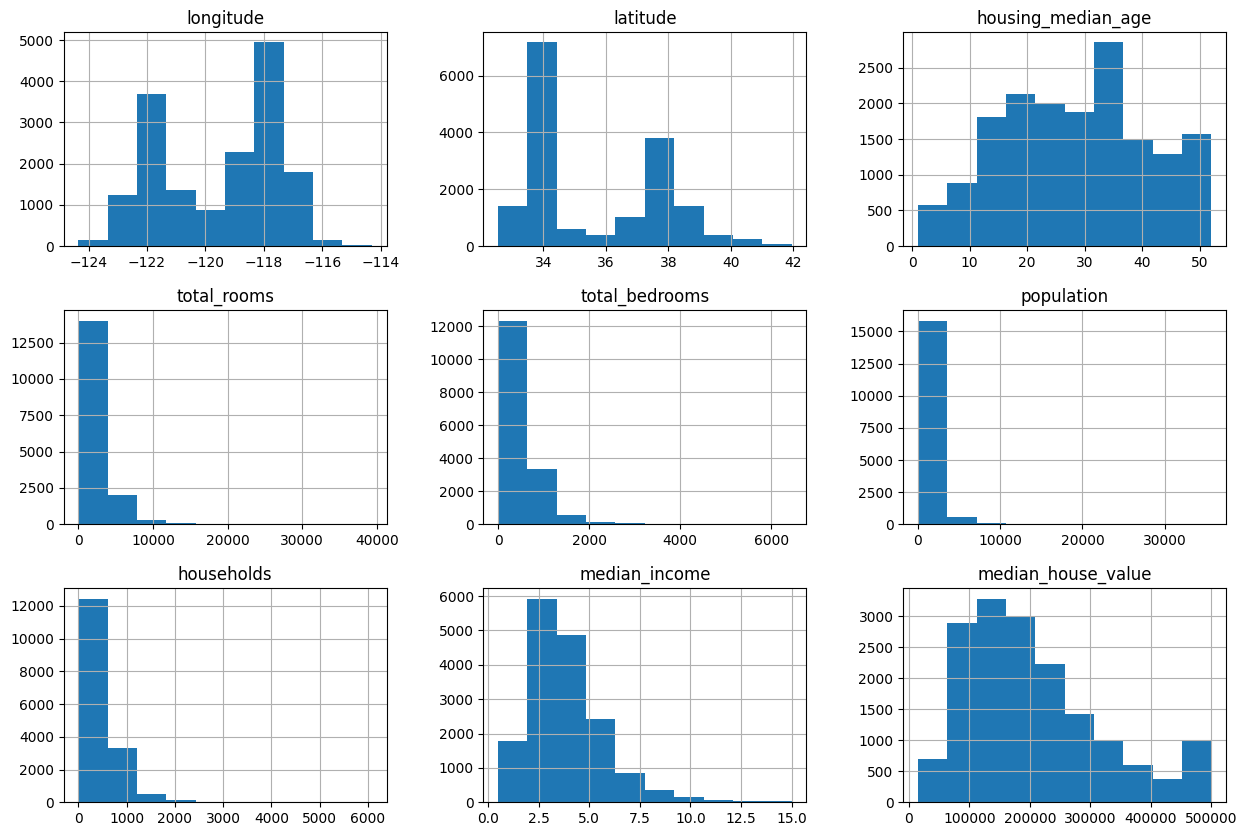

In [57]:
train_data.hist(figsize=(15,10))
plt.show()

In [60]:
train_data.drop('ocean_proximity', axis=1).corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924485,-0.101818,0.038676,0.063064,0.094276,0.049306,-0.017040,-0.046349
latitude,-0.924485,1.000000,0.005296,-0.029224,-0.059998,-0.102499,-0.064061,-0.076571,-0.142983
housing_median_age,-0.101818,0.005296,1.000000,-0.360922,-0.320624,-0.292283,-0.302796,-0.121711,0.103706
total_rooms,0.038676,-0.029224,-0.360922,1.000000,0.930489,0.857936,0.920482,0.198268,0.133989
total_bedrooms,0.063064,-0.059998,-0.320624,0.930489,1.000000,0.878932,0.980255,-0.009141,0.047980
population,0.094276,-0.102499,-0.292283,0.857936,0.878932,1.000000,0.907452,0.004122,-0.026032
households,0.049306,-0.064061,-0.302796,0.920482,0.980255,0.907452,1.000000,0.012776,0.063714
median_income,-0.017040,-0.076571,-0.121711,0.198268,-0.009141,0.004122,0.012776,1.000000,0.690647
median_house_value,-0.046349,-0.142983,0.103706,0.133989,0.047980,-0.026032,0.063714,0.690647,1.000000


In [64]:
X_train=X_train.drop('ocean_proximity', axis=1)

In [65]:
train_data=X_train.join(Y_train)
train_data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0
...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0


In [66]:
train_data.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924485,-0.101818,0.038676,0.063064,0.094276,0.049306,-0.017040,-0.046349
latitude,-0.924485,1.000000,0.005296,-0.029224,-0.059998,-0.102499,-0.064061,-0.076571,-0.142983
housing_median_age,-0.101818,0.005296,1.000000,-0.360922,-0.320624,-0.292283,-0.302796,-0.121711,0.103706
total_rooms,0.038676,-0.029224,-0.360922,1.000000,0.930489,0.857936,0.920482,0.198268,0.133989
total_bedrooms,0.063064,-0.059998,-0.320624,0.930489,1.000000,0.878932,0.980255,-0.009141,0.047980
population,0.094276,-0.102499,-0.292283,0.857936,0.878932,1.000000,0.907452,0.004122,-0.026032
households,0.049306,-0.064061,-0.302796,0.920482,0.980255,0.907452,1.000000,0.012776,0.063714
median_income,-0.017040,-0.076571,-0.121711,0.198268,-0.009141,0.004122,0.012776,1.000000,0.690647
median_house_value,-0.046349,-0.142983,0.103706,0.133989,0.047980,-0.026032,0.063714,0.690647,1.000000


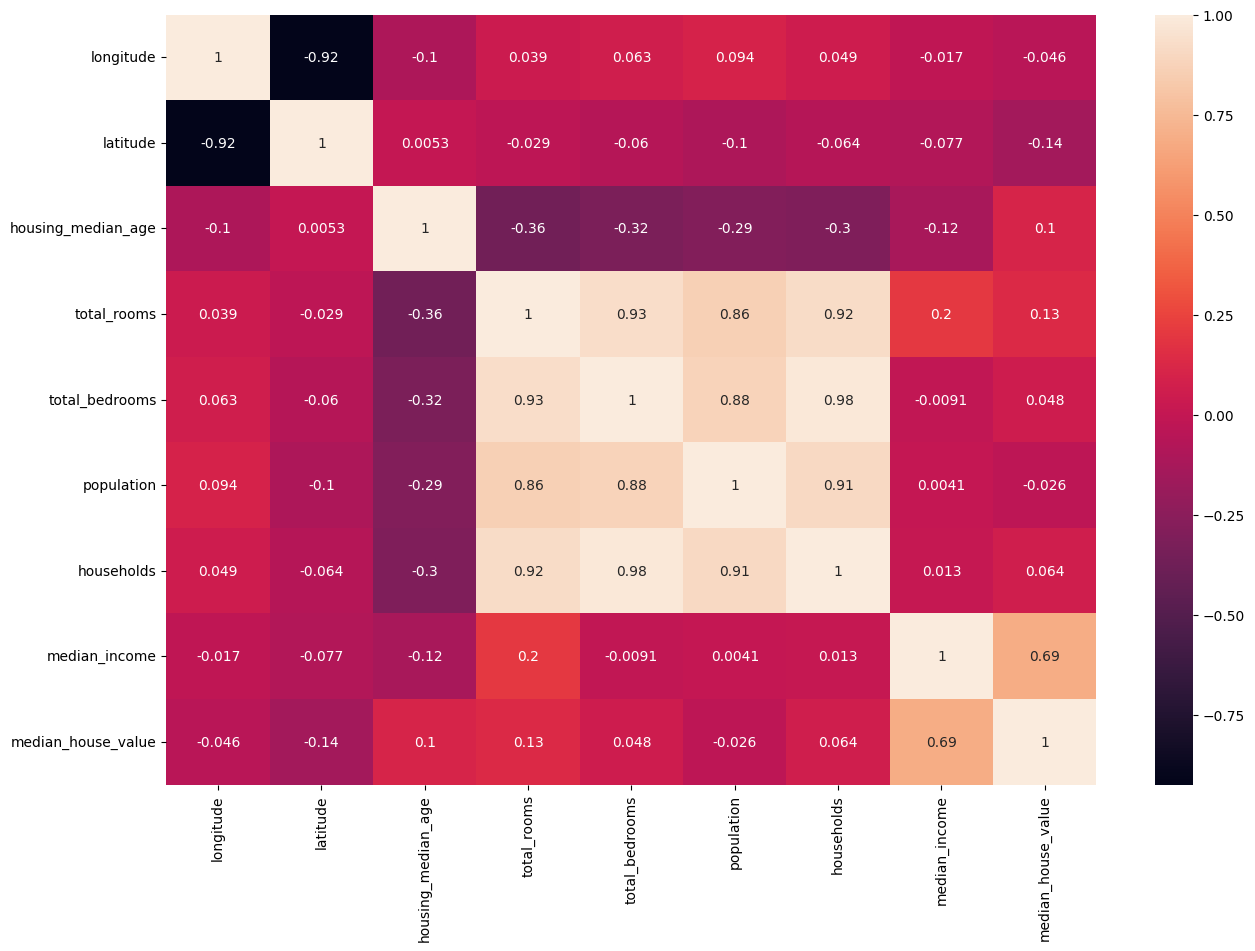

In [69]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(),annot=True)
plt.show()

In [76]:
##data preproccesing
train_data=train_data.join((housing['ocean_proximity']))


In [77]:
train_data["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,7341
INLAND,5227
NEAR OCEAN,2086
NEAR BAY,1854
ISLAND,4


In [80]:
pd.get_dummies(train_data["ocean_proximity"]).astype(int)

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
14196,0,0,0,0,1
8267,0,0,0,0,1
17445,0,0,0,0,1
14265,0,0,0,0,1
2271,0,1,0,0,0
...,...,...,...,...,...
11284,1,0,0,0,0
11964,0,1,0,0,0
5390,1,0,0,0,0
860,1,0,0,0,0


In [84]:
train_data=train_data.drop("ocean_proximity",axis=1)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,0,0,0,0,1
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,0,0,0,0,1
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,0,0,0,0,1
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,0,0,0,0,1
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,1,0,0,0,0
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,0,1,0,0,0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,1,0,0,0,0
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,1,0,0,0,0


In [85]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,0,0,0,0,1
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,0,0,0,0,1
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,0,0,0,0,1
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,0,0,0,0,1
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,1,0,0,0,0
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,0,1,0,0,0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,1,0,0,0,0
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,1,0,0,0,0


<Axes: >

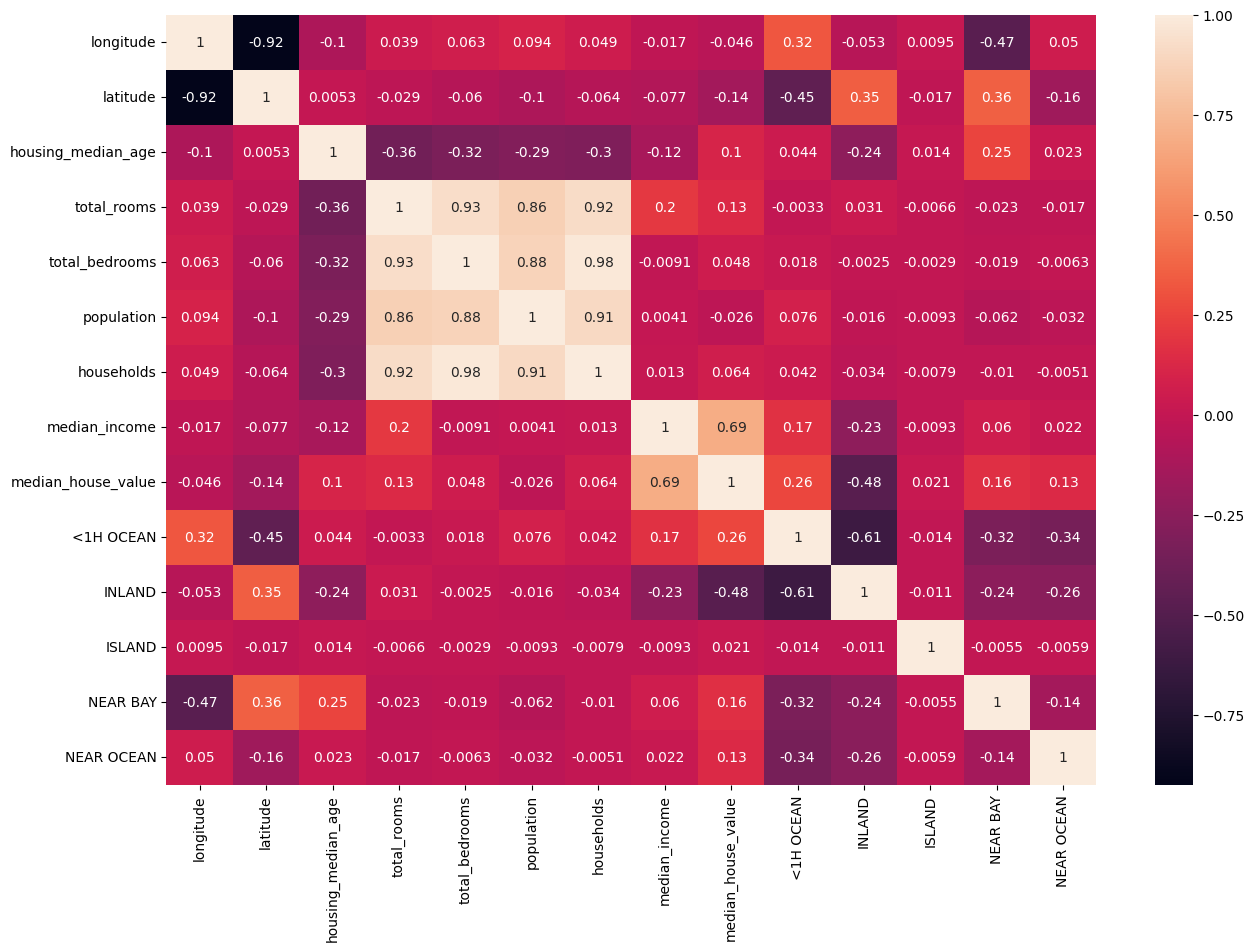

In [87]:
plt.figure(figsize=(15,10)  )
sns.heatmap(train_data.corr(),annot=True  )

In [88]:
X_train=X_train.join((housing['ocean_proximity']))
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND
...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN


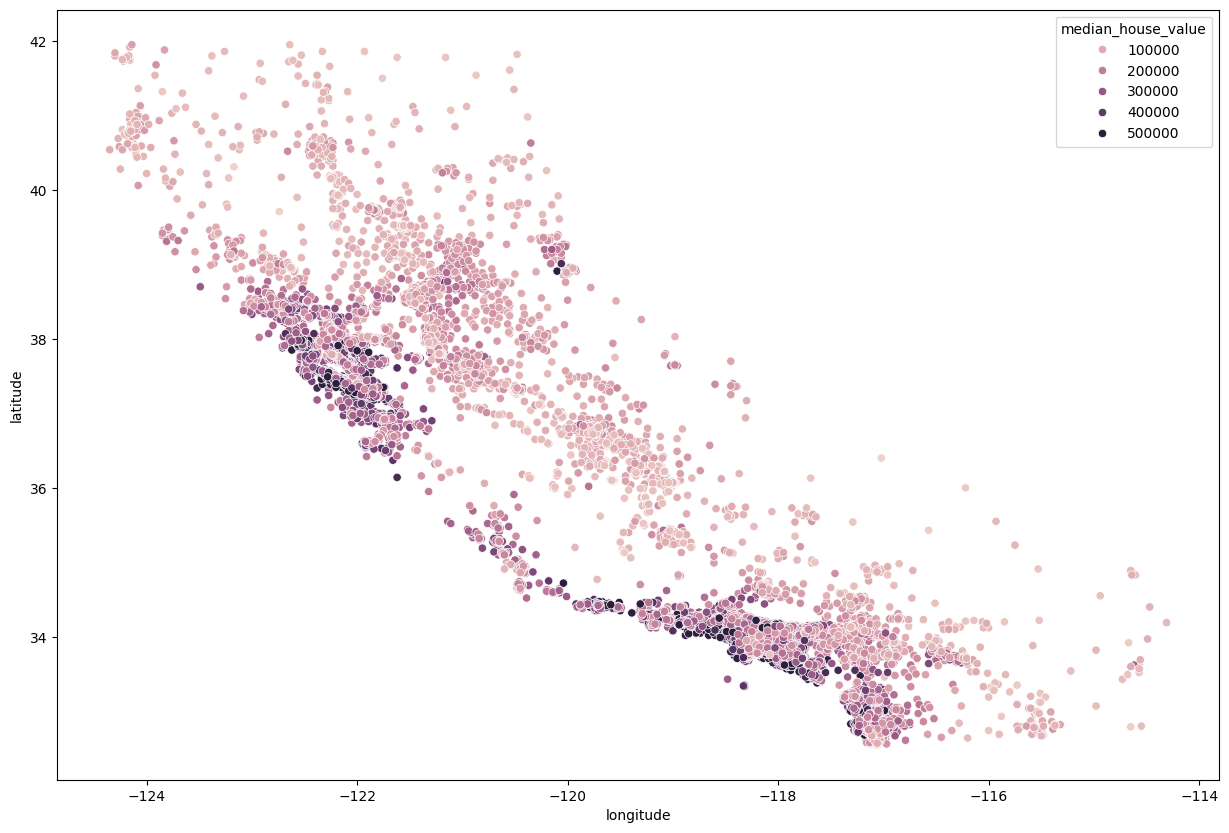

In [93]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=train_data,x='longitude',y='latitude',hue='median_house_value')
plt.show()

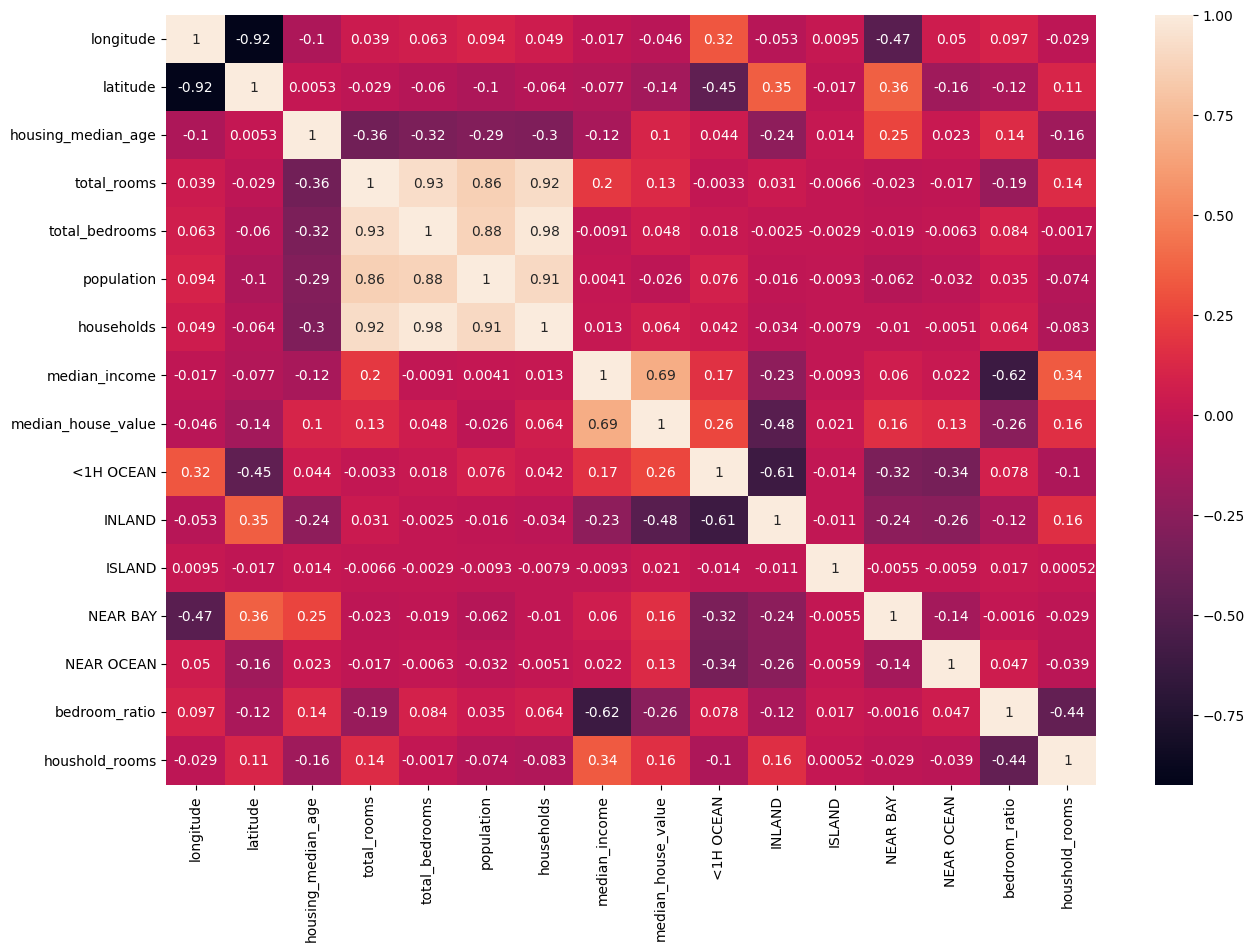

In [98]:
train_data["bedroom_ratio"]=train_data["total_bedrooms"]/train_data["total_rooms"]
train_data["houshold_rooms"]=train_data["total_rooms"]/train_data["households"]
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(),annot=True)
plt.show()

In [99]:
from sklearn.linear_model import LinearRegression
X_trian,Y_train=train_data.drop('median_house_value',axis=1),train_data['median_house_value']
reg=LinearRegression()
reg.fit(X_trian,Y_train)


LinearRegression()

In [100]:
X_trian

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,houshold_rooms
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,0,0,0,0,1,0.200576,5.017657
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,0,0,0,0,1,0.232703,4.473545
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,0,0,0,0,1,0.174486,5.645833
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,0,0,0,0,1,0.258269,4.002817
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,0,1,0,0,0,0.180940,6.268421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,1,0,0,0,0,0.151128,6.129032
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,0,1,0,0,0,0.184825,6.868597
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,1,0,0,0,0,0.270823,3.986717
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,1,0,0,0,0,0.166993,6.395349


In [101]:
test_data=X_test.join(Y_test)
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20046,-119.01,36.06,25.0,1505.0,435.0,1392.0,359.0,1.6812,INLAND,47700.0
3024,-119.46,35.14,30.0,2943.0,435.0,1565.0,584.0,2.5313,INLAND,45800.0
15663,-122.44,37.80,52.0,3830.0,435.0,1310.0,963.0,3.4801,NEAR BAY,500001.0
20484,-118.72,34.28,17.0,3051.0,435.0,1705.0,495.0,5.7376,<1H OCEAN,218600.0
9814,-121.93,36.62,34.0,2351.0,435.0,1063.0,428.0,3.7250,NEAR OCEAN,278000.0
...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,<1H OCEAN,263300.0
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,NEAR OCEAN,266800.0
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,<1H OCEAN,500001.0
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,INLAND,72300.0


In [116]:
test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(["ocean_proximity"],axis=1).astype(int)
test_data


AttributeError: 'DataFrame' object has no attribute 'ocean_proximity'

In [104]:
test_data["bedroom_ratio"]=test_data["total_bedrooms"]/test_data["total_rooms"]
test_data["houshold_rooms"]=test_data["total_rooms"]/test_data["households"]

In [105]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,houshold_rooms
20046,-119.01,36.06,25.0,1505.0,435.0,1392.0,359.0,1.6812,47700.0,False,True,False,False,False,0.289037,4.192201
3024,-119.46,35.14,30.0,2943.0,435.0,1565.0,584.0,2.5313,45800.0,False,True,False,False,False,0.147808,5.039384
15663,-122.44,37.80,52.0,3830.0,435.0,1310.0,963.0,3.4801,500001.0,False,False,False,True,False,0.113577,3.977155
20484,-118.72,34.28,17.0,3051.0,435.0,1705.0,495.0,5.7376,218600.0,True,False,False,False,False,0.142576,6.163636
9814,-121.93,36.62,34.0,2351.0,435.0,1063.0,428.0,3.7250,278000.0,False,False,False,False,True,0.185028,5.492991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,263300.0,True,False,False,False,False,0.152291,7.002212
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,266800.0,False,False,False,False,True,0.204950,6.131915
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,500001.0,True,False,False,False,False,0.130868,7.237676
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,72300.0,False,True,False,False,False,0.185880,5.289030


In [106]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,houshold_rooms
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,0,0,0,0,1,0.200576,5.017657
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,0,0,0,0,1,0.232703,4.473545
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,0,0,0,0,1,0.174486,5.645833
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,0,0,0,0,1,0.258269,4.002817
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,0,1,0,0,0,0.180940,6.268421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,1,0,0,0,0,0.151128,6.129032
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,0,1,0,0,0,0.184825,6.868597
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,1,0,0,0,0,0.270823,3.986717
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,1,0,0,0,0,0.166993,6.395349


In [108]:
X_test,Y_test=test_data.drop('median_house_value',axis=1),test_data['median_house_value']
reg=LinearRegression()



In [109]:
reg.fit(X_test,Y_test)

LinearRegression()

In [110]:
reg.score(X_test,Y_test)

0.633705936071898

In [112]:
X_train
Y_train

,median_house_value
14196,103000.0
8267,382100.0
17445,172600.0
14265,93400.0
2271,96500.0
...,...
11284,229200.0
11964,97800.0
5390,222100.0
860,283500.0


In [113]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,houshold_rooms
20046,-119.01,36.06,25.0,1505.0,435.0,1392.0,359.0,1.6812,False,True,False,False,False,0.289037,4.192201
3024,-119.46,35.14,30.0,2943.0,435.0,1565.0,584.0,2.5313,False,True,False,False,False,0.147808,5.039384
15663,-122.44,37.80,52.0,3830.0,435.0,1310.0,963.0,3.4801,False,False,False,True,False,0.113577,3.977155
20484,-118.72,34.28,17.0,3051.0,435.0,1705.0,495.0,5.7376,True,False,False,False,False,0.142576,6.163636
9814,-121.93,36.62,34.0,2351.0,435.0,1063.0,428.0,3.7250,False,False,False,False,True,0.185028,5.492991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,True,False,False,False,False,0.152291,7.002212
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,False,False,False,False,True,0.204950,6.131915
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,True,False,False,False,False,0.130868,7.237676
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,False,True,False,False,False,0.185880,5.289030


In [114]:
from sklearn.ensemble import RandomForestRegressor
reg=RandomForestRegressor()
reg.fit(X_train,Y_train)


ValueError: could not convert string to float: 'NEAR OCEAN'

In [118]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,houshold_rooms
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,0,0,0,0,1,0.200576,5.017657
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,0,0,0,0,1,0.232703,4.473545
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,0,0,0,0,1,0.174486,5.645833
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,0,0,0,0,1,0.258269,4.002817
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,0,1,0,0,0,0.180940,6.268421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,1,0,0,0,0,0.151128,6.129032
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,0,1,0,0,0,0.184825,6.868597
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,1,0,0,0,0,0.270823,3.986717
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,1,0,0,0,0,0.166993,6.395349


In [120]:
X_train,Y_train=train_data.drop('median_house_value',axis=1),train_data['median_house_value']
reg=RandomForestRegressor()
reg.fit(X_train,Y_train)

RandomForestRegressor()

In [121]:
y_pred=reg.predict(X_test)


In [123]:
from sklearn.metrics import r2_score
r2_score(Y_test,y_pred)

0.8078455308603125

In [125]:
y_pred

array([ 50793.  , 102594.  , 470363.42, ..., 497897.98,  71572.  ,
       168840.  ])

In [126]:
Y_test

,median_house_value
20046,47700.0
3024,45800.0
15663,500001.0
20484,218600.0
9814,278000.0
...,...
15362,263300.0
16623,266800.0
18086,500001.0
2144,72300.0


As you can see, the `True` and `False` values in the one-hot encoded columns are now represented as `1` and `0` respectively. You can then concatenate this `ocean_proximity_dummies` DataFrame with your `train_data` DataFrame and drop the original `ocean_proximity` column.